In [187]:
import os
import numpy as np
import pandas as pd
from sklearn.utils import shuffle
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import models
import albumentations as A
from albumentations.pytorch import ToTensorV2
from tqdm import tqdm
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR


In [188]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
use_amp = torch.cuda.is_available()
print("Using device:", device)


Using device: cpu


In [189]:
import os
import shutil
import random

# Set random seed for reproducibility
random.seed(42)

# Paths
original_images_dir = "./food-101/images"
filtered_images_dir = "./food-101/images_filtered"

# Only include directories as classes (ignore .DS_Store and other files)
all_classes = sorted([
    d for d in os.listdir(original_images_dir)
    if os.path.isdir(os.path.join(original_images_dir, d))
])
selected_classes = all_classes[:6]
print("Selected classes:", selected_classes)

# Create filtered directory
os.makedirs(filtered_images_dir, exist_ok=True)

for class_name in selected_classes:
    class_src = os.path.join(original_images_dir, class_name)
    class_dst = os.path.join(filtered_images_dir, class_name)
    os.makedirs(class_dst, exist_ok=True)
    # Only include image files (ignore .DS_Store or other hidden files)
    images = [f for f in os.listdir(class_src)
              if os.path.isfile(os.path.join(class_src, f)) and not f.startswith('.')]
    selected_images = random.sample(images, 100)
    for img in selected_images:
        shutil.copy(os.path.join(class_src, img), os.path.join(class_dst, img))


Selected classes: ['apple_pie', 'baby_back_ribs', 'baklava', 'beef_carpaccio', 'beef_tartare', 'beet_salad']


In [190]:
import numpy as np
import pandas as pd
from sklearn.utils import shuffle

def prep_df_filtered(images_dir: str) -> pd.DataFrame:
    class_dirs = sorted(os.listdir(images_dir))
    imgs = []
    full_paths = []
    for class_name in class_dirs:
        img_files = os.listdir(os.path.join(images_dir, class_name))
        for img_file in img_files:
            imgs.append([class_name, img_file])
            full_paths.append(os.path.join(images_dir, class_name, img_file))
    imgs = np.array(imgs)
    df = pd.DataFrame(imgs, columns=['label', 'img'])
    df['path'] = full_paths
    df = shuffle(df, random_state=42)
    return df

filtered_images_dir = "./food-101/images_filtered"
df = prep_df_filtered(filtered_images_dir)
print(df['label'].value_counts())

# Label encoder for 6 classes
class Label_encoder:
    def __init__(self, labels):
        self.labels = {label: idx for idx, label in enumerate(labels)}
    def get_label(self, idx):
        return list(self.labels.keys())[idx]
    def get_idx(self, label):
        return self.labels.get(label)

classes_6 = selected_classes
encoder_6 = Label_encoder(classes_6)


label
baby_back_ribs    100
beef_tartare      100
beet_salad        100
apple_pie         100
baklava           100
beef_carpaccio    100
Name: count, dtype: int64


In [191]:
from sklearn.model_selection import train_test_split
from PIL import Image
from torch.utils.data import Dataset

# Train/test split (80/20 stratified)
train_df, test_df = train_test_split(df, test_size=0.2, stratify=df['label'], random_state=42)

class Food6(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe
        self.transform = transform

    def __len__(self):
        return self.dataframe.shape[0]

    def __getitem__(self, idx):
        img_name = self.dataframe.path.iloc[idx]
        image = Image.open(img_name)
        if image.mode != 'RGB':
            image = image.convert('RGB')
        image = np.array(image)
        label = encoder_6.get_idx(self.dataframe.label.iloc[idx])
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented["image"]
        return image, label


In [192]:
import albumentations as A
from albumentations.pytorch import ToTensorV2
from torch.utils.data import DataLoader

train_transform = A.Compose([
    A.Resize(224, 224),
    A.HorizontalFlip(),
    A.Normalize(),
    ToTensorV2(),
])
test_transform = A.Compose([
    A.Resize(224, 224),
    A.Normalize(),
    ToTensorV2(),
])

train_dataset = Food6(train_df, transform=train_transform)
test_dataset = Food6(test_df, transform=test_transform)

trainloader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
testloader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)


In [193]:
import torch
from torchvision import models
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
use_amp = torch.cuda.is_available()
print("Using device:", device)

model = models.resnet152(weights='IMAGENET1K_V2')
model.fc = nn.Linear(model.fc.in_features, len(classes_6))
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=10)
scaler = GradScaler(device.type, enabled=use_amp)


Using device: cpu


In [195]:
from tqdm import tqdm

def train(epoch):
    model.train()
    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for inputs, targets in tqdm(trainloader, desc=f"Training Epoch {epoch + 1}"):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        with autocast(device_type=device.type, enabled=use_amp):
            outputs = model(inputs)
            loss = criterion(outputs, targets)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total_train += targets.size(0)
        correct_train += predicted.eq(targets).sum().item()
    train_accuracy = 100. * correct_train / total_train
    print(f'Training Loss: {running_loss/len(trainloader):.3f} | Training Accuracy: {train_accuracy:.2f}%')
    return train_accuracy


def test(epoch):
    model.eval()
    correct_test = 0
    total_test = 0
    with torch.no_grad():
        for inputs, targets in tqdm(testloader, desc=f"Testing Epoch {epoch + 1}"):
            inputs, targets = inputs.to(device), targets.to(device)
            with autocast(device_type=device.type, enabled=use_amp):
                outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total_test += targets.size(0)
            correct_test += predicted.eq(targets).sum().item()
    test_accuracy = 100. * correct_test / total_test
    print(f'Test Accuracy after Epoch {epoch + 1}: {test_accuracy:.2f}%')
    return test_accuracy


Training Epoch 1: 100%|██████████| 15/15 [02:05<00:00,  8.38s/it]


Training Loss: 1.696 | Training Accuracy: 34.58%


Testing Epoch 1: 100%|██████████| 4/4 [00:17<00:00,  4.31s/it]


Test Accuracy after Epoch 1: 51.67%
Best model saved with accuracy: 51.67%


Training Epoch 2: 100%|██████████| 15/15 [02:05<00:00,  8.36s/it]


...

Test Accuracy after Epoch 9: 80.83%


Training Epoch 10: 100%|██████████| 15/15 [02:04<00:00,  8.29s/it]


Training Loss: 0.015 | Training Accuracy: 100.00%


Testing Epoch 10: 100%|██████████| 4/4 [00:18<00:00,  4.57s/it]

Test Accuracy after Epoch 10: 80.83%
Training completed.


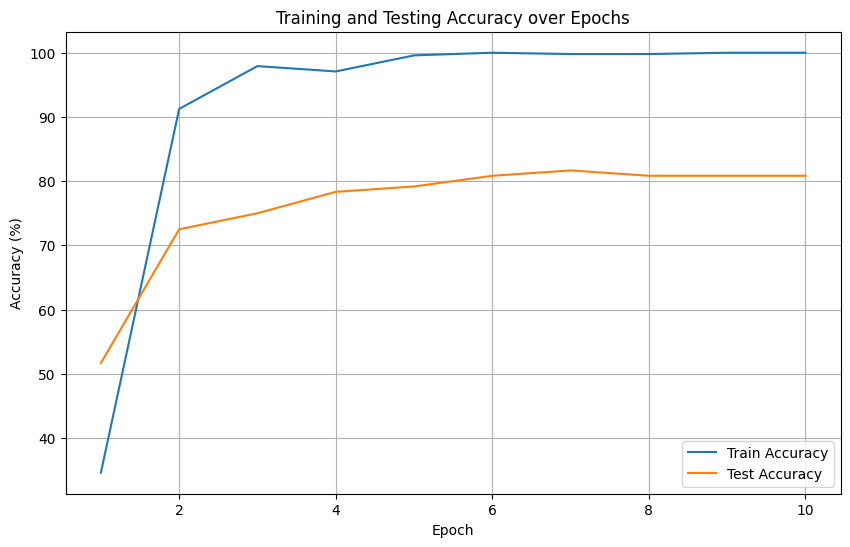

In [196]:
total_epochs = 10
best_acc = 0.0

train_accuracies = []
test_accuracies = []

for epoch in range(total_epochs):
    train_acc = train(epoch)   # Modify train() to return train_accuracy
    test_acc = test(epoch)     # test() already returns test_accuracy
    scheduler.step()
    train_accuracies.append(train_acc)
    test_accuracies.append(test_acc)
    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), 'resnet152_food6_best.pt')
        print(f"Best model saved with accuracy: {best_acc:.2f}%")

print("Training completed.")


import matplotlib.pyplot as plt

epochs = range(1, len(train_accuracies) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, train_accuracies, label='Train Accuracy')
plt.plot(epochs, test_accuracies, label='Test Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Training and Testing Accuracy over Epochs')
plt.legend()
plt.grid(True)
plt.show()
